# Lab 1 Part B: OOP Informed Search Algorithms for Drone Pathfinding

**Duration:** 1 week

**Course topic:** Informed (Heuristic) Search

**Algorithms:** Greedy Best-First Search, A\*, Weighted A\*, Uniform-Cost Search, and (bonus) IDA\*

**Programming style:** Object-Oriented Python

**Prerequisite:** Lab 1 Part A (uninformed search)

---

## Scenario

Your environmental-monitoring drone from Part A is back in the air.

In Part A, the drone searched **blindly**: BFS, DFS, DLS, and IDS had no idea whether a cell was getting closer to the goal or farther away. The drone wasted battery exploring cells that clearly headed in the wrong direction.

Two things have changed:

1. **The drone now has GPS.** It knows its own grid coordinates and the goal's grid coordinates at all times. That means it can *estimate* how far it still has to travel, a **heuristic function** `h(n)`.
2. **The terrain is no longer uniform.** Some cells are easy to fly over (open ground), while others are expensive: strong winds over water bodies, turbulence above dense forest canopy, or detour-altitude requirements over restricted mining zones. Each free cell now has a **traversal cost**, so the cheapest path is not always the shortest one.

In this lab you will implement **informed search strategies** that use `g(n)` (cost already paid), `h(n)` (estimated cost remaining), and `f(n)` (evaluation function) to search far more efficiently than the uninformed strategies from Part A and you will see exactly *when* and *why* Greedy Best-First Search flies the drone straight into a turbulence zone while A\* calmly routes around it.

> Recall the central question from the lecture: *How can an AI agent use domain knowledge to search faster while balancing solution quality, optimality, time, and memory?* This lab answers that question with running code.

# Learning Objectives

By the end of this lab, you should be able to:

1. Explain the difference between uninformed and informed search, in code and in words.
2. Define and implement heuristic functions `h(n)` (Manhattan distance, Euclidean distance).
3. Explain the roles of **g(n)**, **h(n)**, and **f(n)**, and how a **priority queue** orders the frontier.
4. Implement a reusable `BestFirstSearch` framework and derive from it:
   - Greedy Best-First Search (`f(n) = h(n)`),
   - A\* Search (`f(n) = g(n) + h(n)`),
   - Weighted A\* (`f(n) = g(n) + W·h(n)`),
   - Uniform-Cost Search (`f(n) = g(n)`).
5. Extend the grid problem with **non-uniform terrain costs** and explain how this changes which path is optimal.
6. Define **admissibility** and **consistency**, verify them for grid heuristics, and demonstrate experimentally what happens when a heuristic **overestimates**.
7. Evaluate algorithms using solution cost, nodes expanded, maximum frontier size, completeness, and optimality.
8. Choose an appropriate informed search strategy for a given speed / optimality / memory trade-off.

# Submission Instructions

Complete all code cells marked with `TODO`.

Your final notebook must include:

1. Completed implementations of `WeightedGridProblem`, the heuristic functions, `BestFirstSearch`, Greedy Best-First Search, A\*, and Weighted A\*.
2. Output tables comparing the algorithms on the uniform-cost map **and** the weighted-terrain map.
3. Visualisations of at least two solution paths, including one Greedy-vs-A\* comparison on the weighted map.
4. The inadmissible-heuristic experiment with your observations.
5. Answers to all reflection questions.
6. At least two additional maps created by you.
7. The **AI Use Declaration Form**.

Save your completed notebook as:

```text
FirstName_LastName_Lab_1B.ipynb
```

---

## GitHub Submission

You are required to submit your work through GitHub.

1. Use the same GitHub repository as Part A.
2. Add your completed notebook to the repository.
3. Add the AI Usage Declaration Form.
4. Commit and push your final solution to GitHub.
5. Make sure the repository is **public** so that it can be accessed and graded.
6. Submit the **GitHub repository link** on Canvas.

Do **not** submit the `.ipynb` file on Canvas. Canvas should only contain the link to your public GitHub repository.


# 0. How the OOP Design Maps to Informed Search Pseudocode

Part A mapped `problem.ACTIONS(s)`, `problem.RESULT(s, action)`, and `EXPAND(problem, node)` onto methods of `Problem` and `SearchAlgorithm` objects. Part B keeps that design and adds the machinery of informed search:

| Informed search concept | Python/OOP equivalent |
|---|---|
| Heuristic `h(n)` | A plain function `heuristic(state, goal) -> float` passed to the algorithm |
| Path cost `g(n)` | `node.path_cost` (already stored on `Node` from Part A) |
| Evaluation function `f(n)` | `BestFirstSearch.evaluation(node, problem)` — each subclass defines its own |
| Frontier ordered by `f(n)` | `PriorityQueue` built on Python's `heapq` |
| `reached` (best path so far per state) | A **dictionary** `state -> Node`, not just a set |
| Re-discovering a state via a cheaper path | `child.path_cost < reached[s].path_cost` check |

Two important differences from Part A that you must internalise:

1. **`reached` becomes a dictionary.** In BFS a set was enough, because the first time BFS reaches a state is always via a shortest path. With non-uniform costs that is no longer true: a state may be re-discovered later via a *cheaper* path, so we must remember the best `Node` (and its `path_cost`) for each state and be willing to replace it.
2. **The goal test moves to expansion time (the "late goal test").** BFS tested children for the goal as soon as they were *generated*. Best-first search tests a node only when it is *popped* from the priority queue. Why? Because the first goal node generated might not be the cheapest one, a cheaper route to the goal could still be sitting in the frontier. (This is exactly the lecture discussion: *Why does A\* not stop when the goal first appears on the frontier?*)

> The `WeightedGridProblem` knows the drone environment and the terrain costs.
> The heuristic knows the geometry of the grid.
> The search algorithms know only `f(n)` — change `f` and you change the algorithm.

# 1. Setup and Imports

Run the cell below before starting the lab.

In [7]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 2. Foundations from Part A (Provided)

The classes below are a replica of their versions in Part A: the abstract `Problem` interface, the `Node` and `SearchResult` classes, the helper functions, the `GridProblem`, and the shared `expand` method.

In [8]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [9]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [10]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [11]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        legal_actions = []
        row, col = state
        for action, (dr, dc) in MOVES.items():
            neighbour = (row + dr, col + dc)
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1



class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [12]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

# 3. Weighted Terrain: `WeightedGridProblem`

In Part A every move cost exactly 1, so the *shortest* path (fewest moves) was also the *cheapest* path. Real drone flight is not like that. We now attach a **terrain cost** to every free cell:

| Terrain | Example cost | Meaning |
|---|---|---|
| Open ground | `1` | Calm, easy flying |
| Forest canopy | `3` – `5` | Turbulence, slower progress |
| Water body / wind corridor | `5` – `9` | Strong winds, high battery drain |
| Obstacle | `1` in `grid` | Cannot be entered at all |

**Convention:** the cost of a move is the terrain cost of the cell being **entered** (`next_state`). All terrain costs must be **≥ 1**, keep this in mind when we discuss admissibility in Section 4.

`WeightedGridProblem` inherits everything from `GridProblem` and overrides only `action_cost`. This is the OOP payoff: every search algorithm you write in this lab will work on **both** problem classes without changing a single line.

In [13]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        # 2. Return self.terrain_costs[row][col].
        row, col = next_state
        return self.terrain_costs[row][col]

## 3.1 Self-Check for `WeightedGridProblem`

Run this after completing `WeightedGridProblem`. The test grid has a cost-7 cell at `(0, 1)`:

```text
S 7 .
. . .
. . G
```

In [14]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


# 4. Heuristic Functions

A **heuristic function** `h(n)` estimates the cost from a node's state to the goal using domain knowledge. For our drone, the domain knowledge is geometry: GPS gives us the coordinates of the current cell and the goal cell.

In this lab a heuristic is a plain function with the signature:

```python
def heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float
```

You will implement two classic grid heuristics:

**Manhattan distance** — the number of moves needed if there were *no obstacles*:

$$h_{\text{Manhattan}}(n) = |r_n - r_{goal}| + |c_n - c_{goal}|$$

**Euclidean (straight-line) distance** — the length of the straight line between the two cells:

$$h_{\text{Euclidean}}(n) = \sqrt{(r_n - r_{goal})^2 + (c_n - c_{goal})^2}$$

## 4.1 Admissibility and Consistency on Our Grid

Recall from the lecture:

- A heuristic is **admissible** if it **never overestimates** the true remaining cost: `h(n) ≤ h*(n)` for every node. An admissible heuristic is *optimistic*. With an admissible heuristic, A\* is **cost-optimal**.
- A heuristic is **consistent** if it satisfies the triangle inequality: `h(n) ≤ c(n, a, n') + h(n')` for every node `n` and successor `n'`. Every consistent heuristic is admissible (but not vice versa). With a consistent heuristic, the first time A\* pops a state, it has already found the cheapest path to it.

**Think before you code (you will answer these in the reflection questions):**

1. On our 4-connected grid with all terrain costs ≥ 1, is Manhattan distance admissible? *Hint: each move changes exactly one coordinate by exactly 1 and costs at least 1, this is the "relaxed problem" idea from the lecture: Manhattan distance is the exact cost of the relaxed problem with no obstacles and all costs equal to 1.*
2. Is Euclidean distance admissible here? Which of the two is larger, and why does the lecture say a **larger admissible heuristic dominates** a smaller one?
3. Would Manhattan distance still be admissible if some terrain cost were `0.5`? This is why we require all terrain costs ≥ 1.

In [15]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    #
    # Hint: math.sqrt(...) or math.dist(state, goal).
    return math.dist(state, goal)


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

## 4.2 Self-Check for the Heuristics

In [16]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


# 5. The Priority-Queue Frontier (Provided)

BFS used a FIFO queue; DFS used a LIFO stack. Best-first search needs a **priority queue**: it always pops the node with the **lowest `f(n)`**.

The class below wraps Python's `heapq` module. One subtlety is handled for you: `heapq` compares tuples element by element, and `Node` objects are not comparable, so each entry carries a monotonically increasing counter as a tie-breaker. Ties in `f(n)` are therefore broken **first-in, first-out**.

You do not need to modify this class, but read it, because your `BestFirstSearch` implementation will call `push`, `pop`, and `len`.

In [17]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

# 6. The `BestFirstSearch` Framework

Here is the central idea of this entire lab, straight from the lecture's comparison table:

| Algorithm | Evaluation function |
|---|---|
| Greedy Best-First Search | `f(n) = h(n)` |
| A\* Search | `f(n) = g(n) + h(n)` |
| Weighted A\* | `f(n) = g(n) + W·h(n)` |
| Uniform-Cost Search | `f(n) = g(n)` |

They are all the **same algorithm** with a different `f`. So we implement the search loop **once**, in `BestFirstSearch`, and each concrete algorithm only overrides the `evaluation` method.

## Best-First Search Pseudocode Guide

Study this pseudocode before completing the code cell below. Compare it line by line with the BFS pseudocode from Part A and find the three differences (priority queue, `reached` as a dictionary with cost comparison, late goal test).

```text
BEST-FIRST-SEARCH(problem, f)
    node ← NODE(problem.INITIAL)
    frontier ← a priority queue ordered by f, with node as an element
    reached ← a dictionary {problem.INITIAL : node}

    while frontier is not empty do
        node ← POP(frontier)              // node with the LOWEST f-value

        if problem.IS-GOAL(node.STATE) then    // LATE goal test!
            return node

        for each child in EXPAND(problem, node) do
            s ← child.STATE

            if s is not in reached OR child.PATH-COST < reached[s].PATH-COST then
                reached[s] ← child
                add child to frontier with priority f(child)

    return failure
```

**Python structures to think about:** `PriorityQueue` with `push(priority, node)` and `pop()`; `reached` as a `dict` mapping state → `Node`.

**Why the cost comparison?** With non-uniform terrain (or an inconsistent heuristic), a state can be re-discovered later via a cheaper path. The dictionary lets us replace the old, more expensive node. The old entry may still sit in the priority queue, that is fine; when it is eventually popped you could skip it, but for this lab the simple version above is sufficient and still correct, because the cheaper copy will be popped first.

In [18]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        # 5. While the frontier is not empty:
        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.
        node = Node(state=problem.initial_state())
        frontier = PriorityQueue()
        frontier.push(self.evaluation(node, problem), node)
        reached = {node.state: node}
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()
            if problem.is_goal(node.state):
                return SearchResult(algorithm=self.algorithm_name, status="success", solution=node, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size, reached_count=len(reached))
            nodes_expanded += 1
            for child in self.expand(problem, node):
                s = child.state
                if s not in reached or child.path_cost < reached[s].path_cost:
                    reached[s] = child
                    frontier.push(self.evaluation(child, problem), child)
            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(algorithm=self.algorithm_name, status="failure", solution=None, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size, reached_count=len(reached))

# 7. Greedy Best-First Search

**Evaluation function:** `f(n) = h(n)`

Greedy Best-First Search always expands the node that *appears* closest to the goal. It completely ignores `g(n)`, the cost the drone has already paid. Like a pilot who always flies toward the destination without checking the wind: fast decisions, but it may fly straight through a turbulence zone when a calm detour existed.

Properties to remember from the lecture:

- Often finds *a* solution quickly.
- **Not guaranteed to be optimal**, speed of finding a solution does not equal quality of solution.
- Complete on finite state spaces with graph search (our `reached` dictionary provides this).

Thanks to the `BestFirstSearch` framework, the implementation is one line.

In [19]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        return self.h(node, problem)

# 8. A\* Search

**Evaluation function:** `f(n) = g(n) + h(n)`

A\* asks the right question at every node: *"If I go through this node, what is the estimated total cost from start to goal?"* It balances the cost already paid, `g(n)`, against the optimistic estimate of what remains, `h(n)`.

Key properties from the lecture:

- **Complete** - finds a solution if one exists.
- **Cost-optimal** - with an *admissible* heuristic.
- **Optimally efficient** — no other optimal algorithm expands fewer nodes (up to tie-breaking).
- A\* generalises both UCS (`h = 0`) and Greedy (`g` ignored).
- Its weakness is **memory**: the frontier and `reached` structures can grow very large.

Note how the **late goal test** in your `BestFirstSearch.search` is what makes the optimality guarantee work: A\* refuses to declare victory when the goal is merely *generated*, because a cheaper route to the goal might still be waiting in the frontier. The goal is only accepted when it is *popped*, i.e., when no node in the frontier has a lower `f`-value.

In [20]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.
        return node.path_cost + self.h(node, problem)

# 9. Uniform-Cost Search as a Special Case (Provided)

Setting `h(n) = 0` for every node turns A\* into **Uniform-Cost Search**, the informed-search framework with all the information removed. We get it for free, and it gives us a perfect baseline: UCS is optimal but blind, so the gap in *nodes expanded* between UCS and A\* measures exactly how much work the heuristic saves.

In [21]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

# 10. Weighted A\* Search

**Evaluation function:** `f(n) = g(n) + W·h(n)`, with `W > 1`

Sometimes a *good-enough route found now* beats a *perfect route found later*, a drone searching for illegal mining activity before a rainstorm hits cannot wait for the perfectly optimal flight plan. Weighted A\* inflates the heuristic to make the search **greedier**:

| Weight | Behaviour |
|---|---|
| `W = 0` | Uniform-Cost Search |
| `W = 1` | Standard A\* (optimal) |
| `W > 1` | Bounded suboptimal: solution cost ≤ `W ×` optimal, usually far fewer nodes expanded |
| `W → ∞` | Greedy Best-First Search |

This is the lecture's *satisficing search*: we knowingly trade optimality for speed, with a guaranteed bound on how bad the trade can get.

In [22]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n).
        return node.path_cost + self.weight * self.h(node, problem)

## 10.1 Self-Check for the Algorithms

Run this after completing TODOs 4–7. It uses the small test grid from Part A:

```text
S . .
# # .
. . G
```

The only path is `(0,0) → (0,1) → (0,2) → (1,2) → (2,2)`, with cost 4.

In [23]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


# 11. Run the Algorithms on the Part A Sample Map

First, the familiar uniform-cost map from Part A. Because every move costs 1, **all four optimal algorithms should agree on the solution cost** (and it should match the BFS cost you found in Part A: BFS is optimal on unit-cost grids).

What to look at in the table:

- Compare **Nodes expanded** for UCS vs A\*. The difference is the work saved by the Manhattan heuristic, this is the *effective branching factor* idea from the lecture made concrete.
- Compare A\* vs Weighted A\* vs Greedy: fewer nodes, but watch the **Solution cost** column.

In [24]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


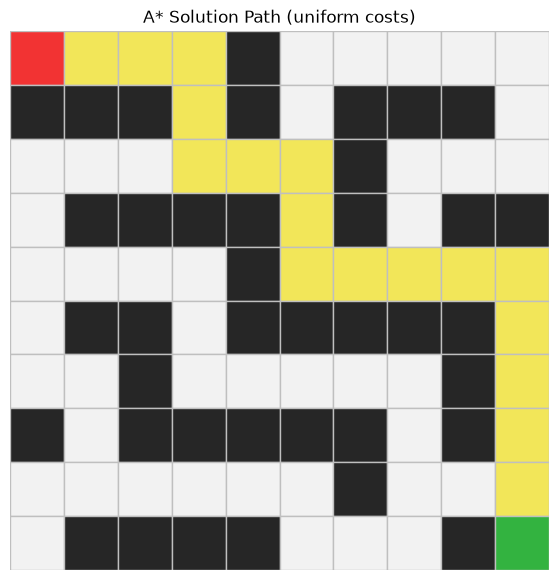

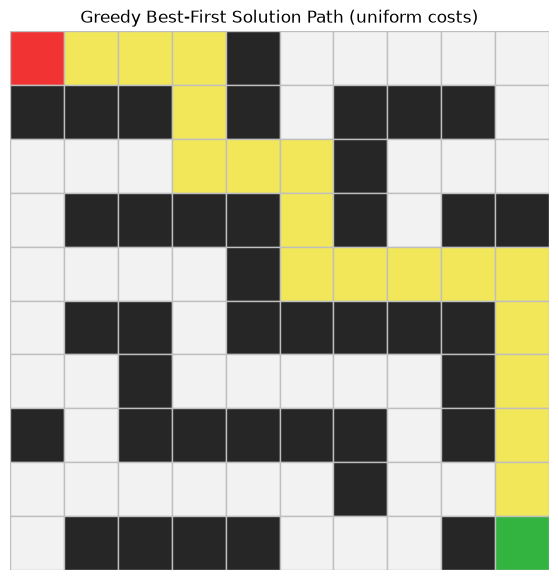

In [25]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

# 12. The Turbulence Map: Where Greedy Goes Wrong

On a uniform-cost grid, Greedy often gets away with ignoring `g(n)`. Weighted terrain exposes it.

The map below has **no obstacles at all** — only terrain costs. A band of severe turbulence (cost 9 per cell) lies directly between the drone and the goal, while calm air (cost 1) runs along the top and bottom edges.

- **Greedy** (`f = h`) sees only that flying straight reduces the Manhattan distance fastest, so it plows directly through the turbulence.
- **A\*** (`f = g + h`) notices that the accumulated cost `g(n)` explodes inside the band and routes around it.

Predict the two path costs before you run the cell. Then check the **Solution cost** column.

In [26]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


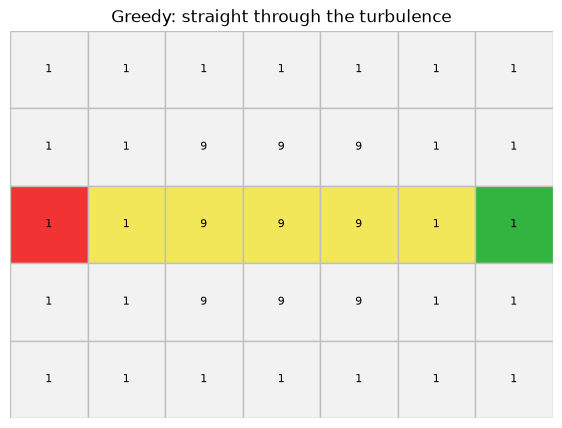

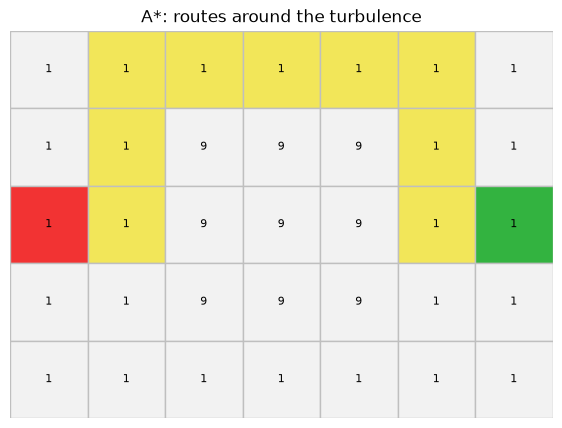

In [27]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

**Checkpoint questions (answer in Section 16):** What were the two solution costs? Did A\* expand more nodes than Greedy here? Why is "Greedy expanded fewer nodes" *not* the same claim as "Greedy is the better algorithm"?

# 13. Experiment: Breaking Admissibility

The lecture claims: *A\* is cost-optimal **with an admissible heuristic**.* Claims in lectures should be tested.

You will build an **inflated heuristic** that multiplies Manhattan distance by a factor `k > 1`. For `k = 3`, the heuristic estimates the remaining cost as three times the relaxed-problem distance, on a unit-cost grid this clearly **overestimates**, so it is *not* admissible.

Then run A\* with the inflated heuristic on the maps and compare against honest A\*.

What you should observe:

- The inflated heuristic typically expands **fewer** nodes (it is more "decisive", this is exactly why Weighted A\* is useful).
- On the *mild turbulence* map below, it returns a **more expensive** path: the optimality guarantee is gone. (On the uniform map it may get lucky, inadmissibility does not mean A\* *always* fails, only that optimality is no longer *guaranteed*.)
- Note that A\* with `3 × h` is mathematically identical to Weighted A\* with `W = 3`, inadmissibility and weighting are two views of the same trade.

In [28]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h
    def h(state, goal):
        return factor * manhattan_distance(state, goal)
    return h


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


**Record your observations in a markdown cell here:**

1. On which map(s) did the inflated heuristic return a suboptimal path? By how much?
2. How many fewer nodes did it expand?
3. In one or two sentences: when would you, as the drone's engineer, deliberately accept an inadmissible heuristic?

*Your answer:*

1. It can be seen that the inflated heuristic returned a suboptimal path on the mild turbulence map.It found a path with cost 12 instead of the optimal cost 10.

2. It can be seen that on the mild turbulence map, the inflated heuristic expanded only 6 nodes compared to 29 for the admissible A*. That is 23 fewer nodes expanded.

3. I think As a drone engineer, I would deliberately accept an inadmissible heuristic when speed matters more than finding the perfect path, for example in a critical delivery time where a slightly longer route is acceptable as long as the drone responds quickly.

# 14. Bonus (Optional): Iterative-Deepening A\* (IDA\*)

A\*'s weakness is memory: `frontier` and `reached` can hold `O(b^d)` nodes. A drone's onboard flight computer may not have that luxury. **IDA\*** is to A\* what IDS (Part A) was to BFS: it runs a depth-first search bounded not by *depth* but by an **f-cost limit**, and raises the limit between iterations.

## IDA\* Pseudocode Guide

```text
IDA-STAR(problem)
    limit ← h(initial)                       // first f-contour

    loop forever:
        result, next_limit ← F-LIMITED-SEARCH(NODE(problem.INITIAL), limit)

        if result is a solution node then return result
        if next_limit = infinity then return failure
        limit ← next_limit                   // smallest f that exceeded the old limit

F-LIMITED-SEARCH(node, limit)                // depth-first, on the current path
    f ← node.PATH-COST + h(node)

    if f > limit then return null, f         // report the overflow value
    if problem.IS-GOAL(node.STATE) then return node, f

    next_limit ← infinity
    for each child in EXPAND(problem, node) do
        if child.STATE is already on the current path then skip it
        result, new_f ← F-LIMITED-SEARCH(child, limit)
        if result is a solution then return result, new_f
        next_limit ← min(next_limit, new_f)

    return null, next_limit
```

This is a stretch goal worth attempting after everything else works. IDA\* uses **linear memory** but may **re-expand** nodes many times — measure both and compare with A\* in your reflection.

In [29]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        # TODO 9 (BONUS, optional):
        # Implement IDA* following the pseudocode guide above.
        #
        # Requirements:
        # 1. Start with limit = h(initial state).
        # 2. Each iteration performs a recursive f-limited depth-first search
        #    that uses path-cycle checking (reuse the idea from DLS in Part A:
        #    skip a child whose state already appears on the current path).
        # 3. Track total nodes_expanded across all iterations and the maximum
        #    recursion depth as max_frontier_size.
        # 4. Keep an iteration log of (limit, outcome) pairs in
        #    SearchResult.iterations.
        # 5. Return status "success", "failure" (next limit is infinity), or
        #    "cutoff" (max_iterations reached).
        raise NotImplementedError("Complete IDAStarSearch.search (bonus)")


# After completing the bonus, compare IDA* with A* here:
# ida = IDAStarSearch(manhattan_distance)
# show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

# 15. Create Your Own Maps

Create at least **two additional maps**. At least one of them must be a `WeightedGridProblem` with meaningful terrain costs.

Design suggestions:

1. A **heuristic trap**: a U-shaped obstacle opening *away* from the goal, so Greedy (and even A\*) must expand many nodes inside the pocket before backing out.
2. A **cheap long way vs expensive short way** map, where the optimal path is much longer (in moves) than the direct path.
3. A larger map, such as 15 × 15 or 20 × 20, to make the UCS-vs-A\* node-count gap dramatic.
4. A map where Weighted A\* with `W = 2` returns a visibly different path from standard A\*.

For each map:

- run UCS, Greedy, A\*, and Weighted A\*,
- record the metrics with `show_results`,
- visualise at least one solution path,
- write a short interpretation (2–4 sentences): which algorithm "won", and on which metric?

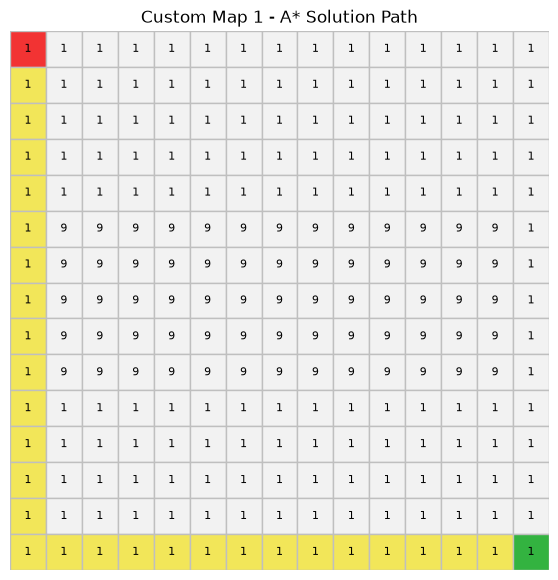

In [30]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    # Replace this with your own grid.
]

custom_costs_1 = [
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,9,9,9,9,9,9,9,9,9,9,9,9,9,1],
    [1,9,9,9,9,9,9,9,9,9,9,9,9,9,1],
    [1,9,9,9,9,9,9,9,9,9,9,9,9,9,1],
    [1,9,9,9,9,9,9,9,9,9,9,9,9,9,1],
    [1,9,9,9,9,9,9,9,9,9,9,9,9,9,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
]

custom_start_1 = (0, 0)
custom_goal_1 = (14, 14)

# Example after completing:
# custom_problem_1 = WeightedGridProblem(
#     custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
# )
# custom_results_1 = [
#     ucs.search(custom_problem_1),
#     astar.search(custom_problem_1),
#     wastar2.search(custom_problem_1),
#     greedy.search(custom_problem_1),
# ]
# show_results(custom_results_1)
custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)

custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]

show_results(custom_results_1)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title="Custom Map 1 - A* Solution Path",
)


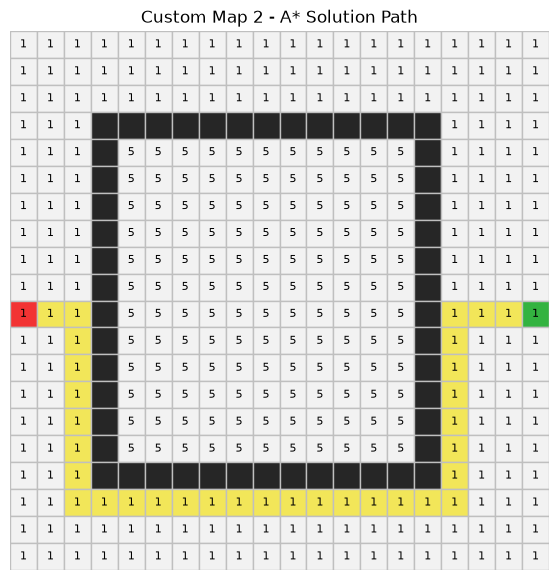

In [31]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
    [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    # Replace this with your own grid.
]

custom_costs_2 = [
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
]

custom_start_2 = (10, 0)
custom_goal_2 = (10, 19)

# Example after completing:
# custom_problem_2 = WeightedGridProblem(
#     custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
# )
# custom_results_2 = [
#     ucs.search(custom_problem_2),
#     astar.search(custom_problem_2),
#     wastar2.search(custom_problem_2),
#     greedy.search(custom_problem_2),
# ]
# show_results(custom_results_2)
custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)

custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]
show_results(custom_results_2)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    terrain_costs=custom_costs_2,
    title="Custom Map 2 - A* Solution Path",
)

# 16. Reflection Questions

Answer the questions below in markdown cells.

## 16.1 Heuristic Functions

1. In your own words, what does `h(n)` estimate, and where does its "knowledge" come from in this lab?
2. Manhattan distance is the exact solution cost of a **relaxed problem**. Which restrictions of the original drone problem does that relaxation remove?
3. Both Manhattan and Euclidean distance are admissible on our grid. Which one **dominates** the other, and what does domination predict about nodes expanded?
4. Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?

## 16.2 Greedy Best-First Search

1. Which quantity does Greedy ignore, and how did the turbulence map punish it for that?
2. Greedy expanded fewer nodes than A\* on some maps. Why is that not enough to call it the better algorithm?
3. Describe a drone mission where Greedy's behaviour would actually be acceptable.

## 16.3 A\* Search

1. Explain `f(n) = g(n) + h(n)` as a sentence about the drone's flight plan.
2. Why must A\* apply the goal test when a node is **popped** rather than when it is **generated**? What could go wrong with an early goal test on the turbulence map?
3. Why does `reached` need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?
4. Compare the nodes expanded by UCS and A\* on the sample map. What does this gap tell you about the value of the heuristic?

## 16.4 Admissibility and Consistency

1. State the definitions of admissible and consistent. Which implies which?
2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?
3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality `h(n) ≤ c(n, a, n') + h(n')` for a single move and explain.

## 16.5 Weighted A\* and Trade-offs

1. How does the weight `W` interpolate between UCS, A\*, and Greedy?
2. What suboptimality bound does Weighted A\* guarantee, and did your experiments stay well inside that bound?
3. The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which `W` would you choose, and why?

## 16.6 Memory and Real-World Drone Context

1. Which data structures make A\* memory-hungry? How does IDA\* (bonus) avoid this, and what does it pay instead?
2. In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts, no-fly zones that change over time, battery state)?
3. Our heuristic assumes the goal never moves. What breaks if the drone is tracking a *moving* target, and which lecture concepts (e.g., learned heuristics, real-time search) become relevant?
4. Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?

# 17. Final Checklist

Before submitting, confirm that:

- [ ] `WeightedGridProblem.action_cost` is complete and its self-check passes.
- [ ] `manhattan_distance` and `euclidean_distance` are complete and their self-check passes.
- [ ] `BestFirstSearch.search` is complete.
- [ ] Greedy Best-First, A\*, and Weighted A\* are complete and the algorithm self-check passes.
- [ ] You ran the comparison on the uniform sample map and on the turbulence map.
- [ ] You visualised the Greedy-vs-A\* paths on the turbulence map.
- [ ] You completed the inadmissible-heuristic experiment and wrote your observations.
- [ ] You created at least two custom maps (at least one weighted) with results, a visualisation, and an interpretation each.
- [ ] You answered all reflection questions.
- [ ] (Bonus) IDA\* is implemented and compared with A\*.
- [ ] Your AI Use Declaration is included.
- [ ] The notebook runs from top to bottom without errors.
- [ ] Your notebook filename follows the required format and your GitHub repository is public.

REFLECTION QUESTION 16.1
1. h(n) estimates the cost still needed to reach the goal from the current position. In this lab its knowledge comes from the concept of geometry. This is because, the drone knows its own coordinates and the goal coordinates so it can calculate the distance without knowing anything about obstacles.

2. Manhattan distance is the exact cost when there are no obstacles and all terrain costs are 1. The relaxation removes two restrictions. One, it ignores 
walls and obstacles, and secondly it assumes every cell costs exactly 1 to enter.

3. Manhattan distance dominates Euclidean distance because it is always greater than or equal to Euclidean distance on a grid. A dominating heuristic is closer to the true cost, so A* with Manhattan distance will expand fewer nodes than A* with Euclidean distance.

4.If all terrain costs are at least 1, then each move costs at least 1, so Manhattan distance never overestimates. But if a terrain cost were 0.5, a move could cost less than 1, meaning Manhattan distance could overestimate the true cost and lose its admissibility.

Q16.2
1. Greedy ignores g(n) — the actual cost already paid to reach the current position. On the turbulence map this meant it flew straight through the high-cost cells because they looked close to the goal, ending up with a solution cost of 30 instead of the optimal 10.

2. This is because, expanding fewer nodes only means it is faster but not necessarily the best. A faster algorithm that finds a worse path is not better overall. What matters is the quality of the solution found, and Greedy's path is not optimal.

3. Greedy's behaviour would be acceptable in a time-critical rescue mission where the drone needs to reach a location as fast as possible and a slightly suboptimal route is fine as long as it gets there quickly.

Q16.3
1. f(n) = g(n) + h(n) means the drone considers both how much battery it has already used to reach its current position and how much it estimates it still needs to reach the goal, choosing the path that minimises the total.

2. A* must apply the goal test when a node is popped because a node generated early may later be reached via a cheaper path. On the turbulence map, a node near the goal might be generated through the expensive turbulence zone first, but later reached more cheaply by going around. Testing early would return the expensive path as the solution.

3. reached needs to be a dictionary in this lab because terrain costs mean the same state can be reached via different paths with different costs. 
The dictionary lets us check if we found a cheaper path to an already visited state and update it. In BFS with uniform costs, the first time a state is reached is always the cheapest, so a plain set was enough.

4. UCS expanded 52 nodes while A* expanded only 18 on the sample map. This gap shows that the Manhattan heuristic saved A* from exploring 34 extra nodes by pointing it in the right direction. The better the heuristic, the less unnecessary work the algorithm does.
